In [1]:
#Task 4 - Data Visualization and Analysis - all analysis is done using the clean dataset
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("medical_insurance_cleaned.csv")
#Key categories to analyze: risk score vs controllable variables
#such as bmi, income, smoker, alcohol_freq, urban_rural and how they affect risk score
# by understanding the relationships, we may be able to identify areas for intervention to reduce risk score and improve patient outcomes.

In [2]:
#Begin with summaries of the data to get a sense of the distribution of the variables
num_features = ["bmi", "income", "risk_score"]
categorical_features = ["smoker", "alcohol_freq", "urban_rural"]
print("Summary statistics for the numerical variables in the dataset:")
print(df[num_features].describe())



Summary statistics for the numerical variables in the dataset:
                 bmi        income     risk_score
count  100000.000000  1.000000e+05  100000.000000
mean       26.990512  4.987390e+04       0.519849
std         4.994883  4.680021e+04       0.250669
min        12.000000  1.100000e+03       0.000000
25%        23.600000  2.110000e+04       0.329700
50%        27.000000  3.620000e+04       0.505500
75%        30.400000  6.220000e+04       0.703300
max        50.400000  1.061800e+06       1.000000


In [3]:
#the majority of patients have a BMI between 20 and 40, with a few outliers having a BMI above 40. The median BMI is around 27, which is considered slightly overweight.
skew_results = df[num_features].skew().round(2)
print(skew_results)

#then we can visualize the relationships between the risk score and the controllable variables using scatter plots for numerical variables and box plots for categorical variables. This will help us identify any patterns or trends in the data that may be useful for intervention strategies.

bmi           0.02
income        3.39
risk_score    0.16
dtype: float64


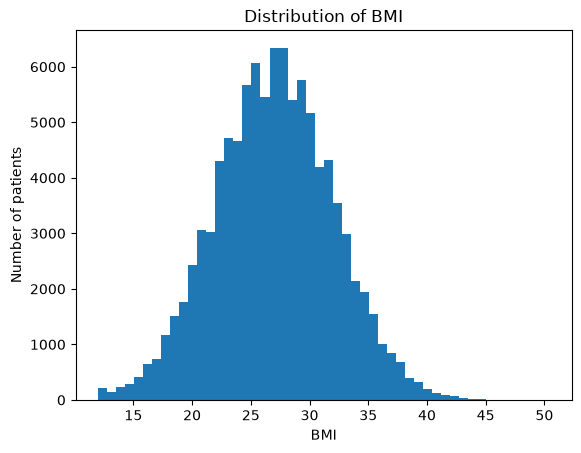

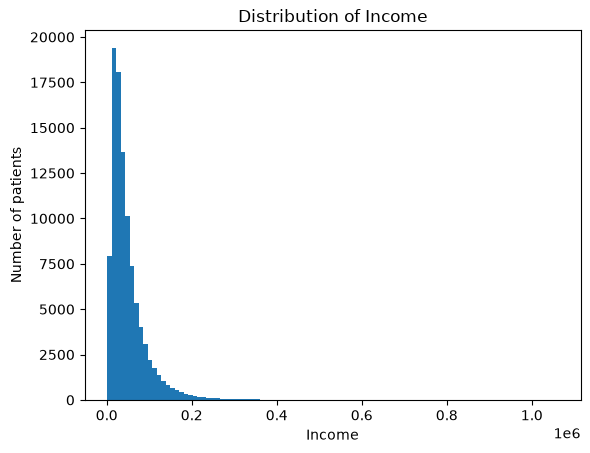

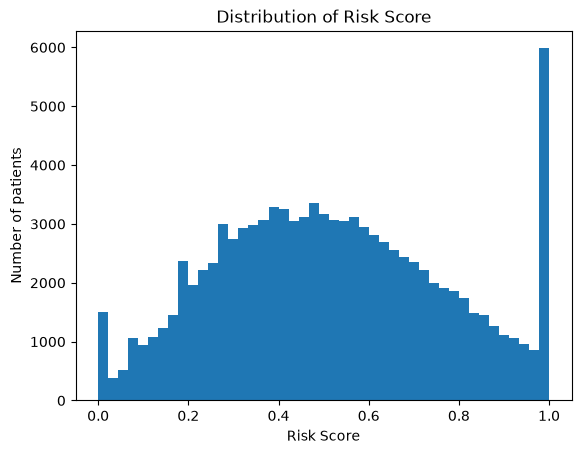

In [4]:
#Histograms of the numerical variables to visualize the distribution of the data
import matplotlib.pyplot as plt

plt.hist(df["bmi"].dropna(), bins=50)
plt.xlabel("BMI"); plt.ylabel("Number of patients")
plt.title("Distribution of BMI")
plt.show()

plt.hist(df["income"].dropna(), bins=100)
plt.xlabel("Income"); plt.ylabel("Number of patients")
plt.title("Distribution of Income")
plt.show()

plt.hist(df["risk_score"].dropna(), bins=45)
plt.xlabel("Risk Score"); plt.ylabel("Number of patients")
plt.title("Distribution of Risk Score")
plt.show()

#from the histograms, we can see that age is roughly normally distributed, with a slight skew to the right. BMI is also roughly normally distributed, with a slight skew to the right. Risk score is heavily skewed to the right, with most patients having a low risk score and a few outliers having a high risk score. Chronic count is also heavily skewed to the right, with most patients having a low number of chronic conditions and a few outliers having a high number of chronic conditions.

In [5]:
#How many patients have a risk score of 0, and how many have a risk score of 1 or higher
print("people with risk score = 0: " + str(df[df["risk_score"] == 0].shape[0]))
print("people with risk score >= 1: " + str(df[df["risk_score"] >= 1].shape[0]))

#1131 patients have a risk score of 0, and 5241 patients have a risk score of 1 or higher.

people with risk score = 0: 1131
people with risk score >= 1: 5241


In [6]:
import numpy as np

def calculate_kruskal(df, group_col, target_col='risk_score'):
    # Drop rows with missing values
    clean = df[[group_col, target_col]].dropna()
    
    # Extract unique categories
    categories = clean[group_col].unique()
    k = len(categories)
    N = len(clean)
    
    # Combine and rank all target values (assign average ranks for ties)
    vals = clean[target_col].values
    ranks = np.argsort(np.argsort(vals)) + 1.0
    
    # Calculate sum of ranks squared divided by sample size for each group
    rank_sum_sq = 0
    for cat in categories:
        mask = (clean[group_col] == cat).values
        n_i = np.sum(mask)
        R_i = np.sum(ranks[mask])
        rank_sum_sq += (R_i ** 2) / n_i
        
    # Calculate Kruskal-Wallis H statistic
    H = (12.0 / (N * (N + 1))) * rank_sum_sq - 3.0 * (N + 1)
    
    # Degrees of freedom = number of groups - 1
    df_val = k - 1
    
    print(f"Feature: {group_col:<15} | H-Stat: {H:8.4f} | df: {df_val}")
    return H

# Run test on all categorical features
for col in ['urban_rural', 'smoker', 'alcohol_freq']:
    calculate_kruskal(df, col)

Feature: urban_rural     | H-Stat:   2.4370 | df: 2
Feature: smoker          | H-Stat: 9891.0617 | df: 2
Feature: alcohol_freq    | H-Stat:   0.4197 | df: 2


In [7]:
import numpy as np
 
def calculate_anova(df, group_col, target_col='risk_score'):
    clean = df[[group_col, target_col]].dropna()
    categories = clean[group_col].unique()
    
    overall_mean = np.mean(clean[target_col].values)
    k = len(categories)
    N = len(clean)
    
    ss_between = 0
    ss_within = 0
    
    for cat in categories:
        group_vals = clean[clean[group_col] == cat][target_col].values
        n_i = len(group_vals)
        group_mean = np.mean(group_vals)
        
        # Variance between group mean and overall mean
        ss_between += n_i * ((group_mean - overall_mean) ** 2)
        # Variance inside the group
        ss_within += np.sum((group_vals - group_mean) ** 2)
        
    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (N - k)
    
    # Calculate F statistic
    F = ms_between / ms_within
    print(f"Feature: {group_col:<15} | F-Stat: {F:8.4f} | df: ({k-1}, {N-k})")
    return F

for col in ['urban_rural', 'smoker', 'alcohol_freq']:
    calculate_anova(df, col)

Feature: urban_rural     | F-Stat:   1.3223 | df: (2, 99997)
Feature: smoker          | F-Stat: 5789.6088 | df: (2, 99997)
Feature: alcohol_freq    | F-Stat:   0.4345 | df: (2, 69914)


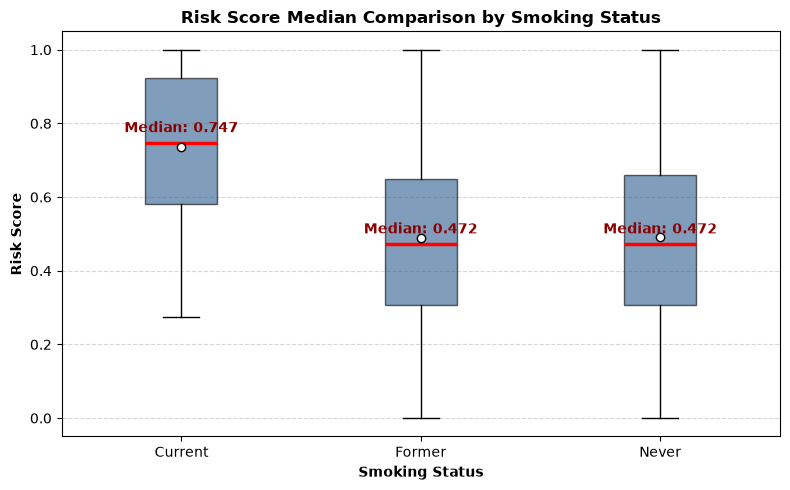

In [16]:
#BOXPLOT OF SMOKER

import matplotlib.pyplot as plt

# Group data by smoker category
groups = df.groupby('smoker', observed=False)['risk_score']
labels = [str(name) for name, _ in groups]
data = [group.dropna().values for _, group in groups]

# Calculate exact medians for annotation
medians = [np.median(d) for d in data]

fig, ax = plt.subplots(figsize=(8, 5))

# Draw Boxplot (The center line inside each box IS the median)
bp = ax.boxplot(
    data, 
    tick_labels=labels, 
    patch_artist=True,
    showmeans=True, # White circle = Mean, Black line = Median
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
    medianprops={"color": "red", "linewidth": 2.5}, # Highlight median in bold red
    boxprops={"facecolor": "#2b5c8f", "alpha": 0.6}
)

# Annotate exact median values directly on top of the median lines
for i, median_val in enumerate(medians):
    ax.text(
        i + 1, median_val + 0.02, f"Median: {median_val:.3f}", 
        ha='center', va='bottom', fontweight='bold', color='darkred'
    )

ax.set_title('Risk Score Median Comparison by Smoking Status', fontweight='bold')
ax.set_xlabel('Smoking Status', fontweight='bold')
ax.set_ylabel('Risk Score', fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()